# 📊 YouTube Analytics — Combine & EDA

**Ironhack Data Analytics — Module 1 Project** · Team: Pariya & Zahid

This notebook **combines** the two cleaned datasets and answers our research questions.

| File | Source | Rows | Period |
|---|---|---|---|
| `api_clean.csv` | YouTube Data API (notebook 01) | 200 | one day in 2026 |
| `kaggle_clean.csv` | Kaggle dataset (notebook 02) | ≈55,000 | Aug 2020 – Apr 2024 |

**Main question:** *What drives engagement on trending YouTube videos in Germany?*

| # | Question | Hypothesis | Data used |
|---|---|---|---|
| 1 | Does **video length** affect engagement? (Shorts vs. long + length groups) | Shorter videos (incl. Shorts) get more likes & comments per view | API (Kaggle has no duration) |
| 2 | Which **category** gets the most engagement? | Music has the highest engagement | API + Kaggle (then vs. now) |
| 3 | Does **publish time** matter? | Videos published on weekends get more views | Kaggle (API has a Monday bias) |
| 4 | Do **clickbait titles** get more views? | Titles with `!`, `?` or CAPS words get more views | Kaggle |

## 1. Setup

In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load & combine the data

### 2.1 Load both clean files


In [3]:
api = pd.read_csv("api_clean.csv")
kaggle = pd.read_csv("kaggle_clean.csv")

print("API:   ", api.shape)
print("Kaggle:", kaggle.shape)

API:    (200, 15)
Kaggle: (55467, 15)


### 2.2 Check that the columns match

Both files must have **the same columns**, otherwise `concat` creates extra columns full of NaN.

In [4]:
set(api.columns)==set(kaggle.columns)

True

### 2.3 Combine with `concat`

`concat` puts the two tables **on top of each other**.
`ignore_index=True` gives the new table a clean index (0, 1, 2, …).

In [5]:
df=pd.concat([api,kaggle],ignore_index=True)
df.head()

,video_id,title,channel,category_id,published_at,views,likes,comments,publish_weekday,publish_hour,duration_sec,like_rate,comment_rate,category_name,period
0,s_JQEVcu9yI,Bujar Mustafa - Belaja,BM Official,10,2026-09-28 17:00:06+02:00,139332,2760.0,100.0,Monday,17,163.0,1.980880,0.071771,Music,2026
1,JZZz8m0N3t8,ASTERIX UND DAS KÖNIGREICH NUBIEN Trailer 2 Ge...,KinoCheck,24,2026-09-28 13:03:03+02:00,149592,1363.0,139.0,Monday,13,145.0,0.911145,0.092919,Entertainment,2026
2,wFDj6uL_iK8,MIMIC PARTY IN TEAMS,LUCREW,24,2026-09-28 16:00:36+02:00,252261,10704.0,294.0,Monday,16,891.0,4.243224,0.116546,Entertainment,2026
3,6Ws4ydd85wU,MEHNERSMOOS - Intro,Mehnersmoos,10,2026-09-28 12:00:11+02:00,52398,3631.0,287.0,Monday,12,274.0,6.929654,0.547731,Music,2026
4,uvDjQokpKUo,THE MORTUARY ASSISTANT Trailer German Deutsch ...,KinoCheck Heimkino,24,2026-09-28 16:06:41+02:00,23309,164.0,15.0,Monday,16,129.0,0.703591,0.064353,Entertainment,2026


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55667 entries, 0 to 55666
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   video_id         55667 non-null  object 
 1   title            55667 non-null  object 
 2   channel          55667 non-null  object 
 3   category_id      55667 non-null  int64  
 4   published_at     55667 non-null  object 
 5   views            55667 non-null  int64  
 6   likes            55384 non-null  float64
 7   comments         54770 non-null  float64
 8   publish_weekday  55667 non-null  object 
 9   publish_hour     55667 non-null  int64  
 10  duration_sec     200 non-null    float64
 11  like_rate        55384 non-null  float64
 12  comment_rate     54770 non-null  float64
 13  category_name    55667 non-null  object 
 14  period           55667 non-null  object 
dtypes: float64(5), int64(3), object(7)
memory usage: 6.4+ MB


A CSV only stores text, so some types get lost:
- `published_at` → back to **datetime** in German time
  (`utc=True` is needed because the file has two offsets: `+01:00` in winter, `+02:00` in summer)

In [7]:
df['published_at'] = pd.to_datetime(df['published_at'],utc=True).dt.tz_convert('Europe/Berlin')
df['published_at']


0       2026-09-28 17:00:06+02:00
1       2026-09-28 13:03:03+02:00
2       2026-09-28 16:00:36+02:00
3       2026-09-28 12:00:11+02:00
4       2026-09-28 16:06:41+02:00
                   ...           
55662   2021-05-11 17:00:09+02:00
55663   2024-02-05 18:02:00+01:00
55664   2020-11-25 09:00:00+01:00
55665   2021-06-08 08:37:10+02:00
55666   2021-01-22 00:07:57+01:00
Name: published_at, Length: 55667, dtype: datetime64[ns, Europe/Berlin]

In [8]:
df['period'].unique()

array([2026, '2020-2024'], dtype=object)

In [9]:
df["period"] = df["period"].astype(str)
df["period"].unique()

array(['2026', '2020-2024'], dtype=object)

### 2.4 API data only

Questions 1 and 2 need `duration_sec`, which only exists in the **API data**.
So we create `api_df` with only the 2026 rows (200 videos).
`.copy()` makes a separate table, so new columns we add later don't change `df`.

In [10]:
api_df = df[df["period"]=="2026"].copy()
api_df.shape

(200, 15)

---
## 3. Question 1: Does video length affect engagement? (API data)

We look at length in two ways:
- **3.1 Shorts vs. long videos**
- **3.2 Length groups**

### 3.1 Shorts vs. long videos

A video of **3 minutes or less** counts as a Short (the API has no Short label).

In [11]:
#which videos are short
api_df["is_short"]=api_df['duration_sec']<=180
api_df["is_short"].value_counts()

is_short
False    185
True      15
Name: count, dtype: int64

In [12]:
shorts_summary = api_df.groupby('is_short')[['comment_rate','like_rate']].median()
shorts_summary

,comment_rate,like_rate
is_short,,
False,0.131713,2.683386
True,0.091302,1.736808


In [13]:
shorts_summary.index=["long(> 3 min)" , "short(<3 min)"]

In [14]:
shorts_summary

,comment_rate,like_rate
long(> 3 min),0.131713,2.683386
short(<3 min),0.091302,1.736808


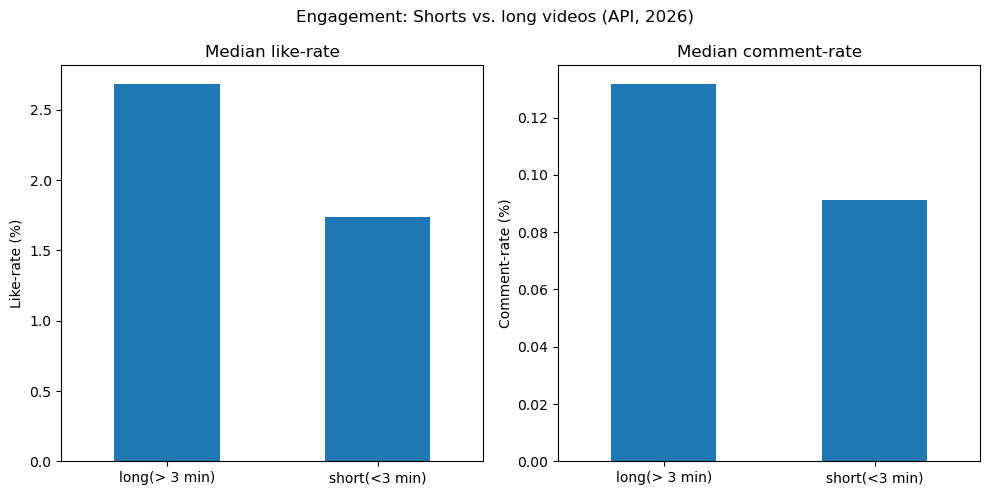

In [15]:
fig , axes = plt.subplots(1,2,figsize=(10,5))
shorts_summary['like_rate'].plot(kind='bar',ax=axes[0])
axes[0].set_title("Median like-rate")
axes[0].set_ylabel("Like-rate (%)")
axes[0].tick_params(axis="x", rotation=0)

shorts_summary['comment_rate'].plot(kind='bar',ax=axes[1])
axes[1].set_title("Median comment-rate")
axes[1].set_ylabel("Comment-rate (%)")
axes[1].tick_params(axis="x", rotation=0)
plt.suptitle("Engagement: Shorts vs. long videos (API, 2026)")
plt.tight_layout()
plt.show()

**Result:** Long videos have a **higher engagement** than Shorts:
- Median like-rate: **2.68%** (long) vs. **1.74%** (Shorts)
- Median comment-rate: **0.13%** (long) vs. **0.09%** (Shorts)

→ **Hypothesis 1 is not supported** ❌

⚠️ Only **15 of 200** trending videos are Shorts, so this result is based on a small group.
A possible reason: viewers of long videos spend more time with a channel and are more likely to like and comment.

### 3.2 Length groups

In [16]:
bins = [0, 60, 300, 600, 1200, 3600, 100000]
labels = ["< 1 min", "1-5 min", "5-10 min", "10-20 min", "20-60 min", "> 1 h"]

api_df["length_group"] = pd.cut(api_df["duration_sec"], bins=bins, labels=labels)

In [17]:
api_df['length_group'].value_counts().sort_index()

length_group
< 1 min       1
1-5 min      27
5-10 min      5
10-20 min    33
20-60 min    99
> 1 h        35
Name: count, dtype: int64

In [18]:
length_summary = api_df.groupby("length_group", observed=True)[["like_rate", "comment_rate"]].median()
length_summary

,like_rate,comment_rate
length_group,,
< 1 min,2.936585,0.295740
1-5 min,1.740536,0.072922
5-10 min,2.937596,0.184184
10-20 min,2.431611,0.195792
20-60 min,2.787456,0.122677
> 1 h,2.218664,0.087504


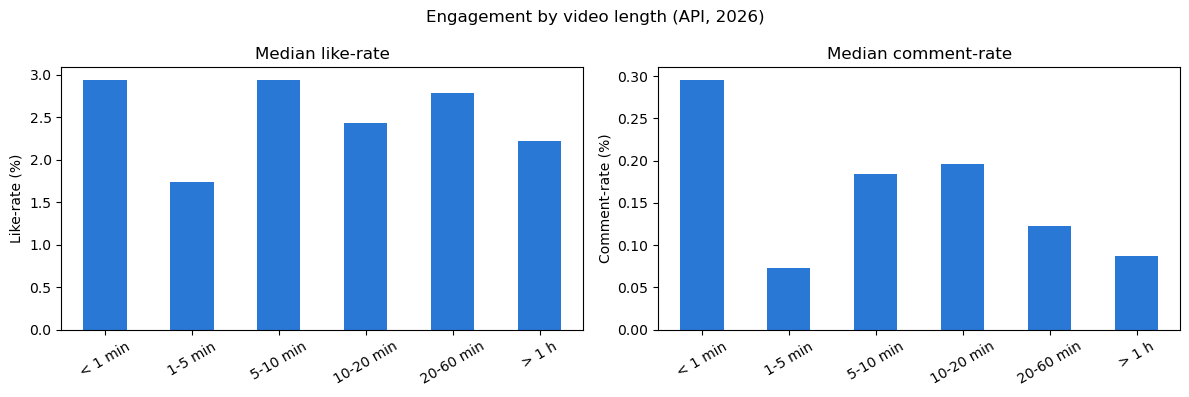

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left chart: like-rate
length_summary["like_rate"].plot(kind="bar", ax=axes[0], color="#2a78d6")
axes[0].set_title("Median like-rate")
axes[0].set_ylabel("Like-rate (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

# right chart: comment-rate
length_summary["comment_rate"].plot(kind="bar", ax=axes[1], color="#2a78d6")
axes[1].set_title("Median comment-rate")
axes[1].set_ylabel("Comment-rate (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Engagement by video length (API, 2026)")
plt.tight_layout()
plt.show()

**Result:**

| Length | Videos | Median like-rate | Median comment-rate |
|---|---|---|---|
| < 1 min | 1 ⚠️ | 2.94% | 0.30% |
| 1–5 min | 27 | **1.74%** (lowest) | 0.07% |
| 5–10 min | 5 ⚠️ | 2.94% | 0.18% |
| 10–20 min | 33 | 2.43% | 0.20% |
| 20–60 min | 99 | **2.79%** (highest) | 0.12% |
| > 1 h | 35 | 2.22% | 0.09% |

⚠️ The groups "< 1 min" (1 video) and "5–10 min" (5 videos) are too small to be reliable, so we don't use them for conclusions.

**Insights:**
- **20–60 minute videos dominate** the trending list: 99 of 200 videos (≈50%).
- Among the groups with enough videos, **20–60 min videos have the highest like-rate (2.79%)**.
- **Short videos (1–5 min) have the lowest like-rate (1.74%)**. This matches our Shorts result (Question 1).

→ **Hypothesis 2 ("shorter videos get more engagement") is not supported** ❌
Longer videos seem to create a stronger connection with viewers, who then like and comment more.

---
## 4. Question 2: Which category gets the most engagement? (then vs. now)

*Engagement rate = like-rate + comment-rate (in %).*

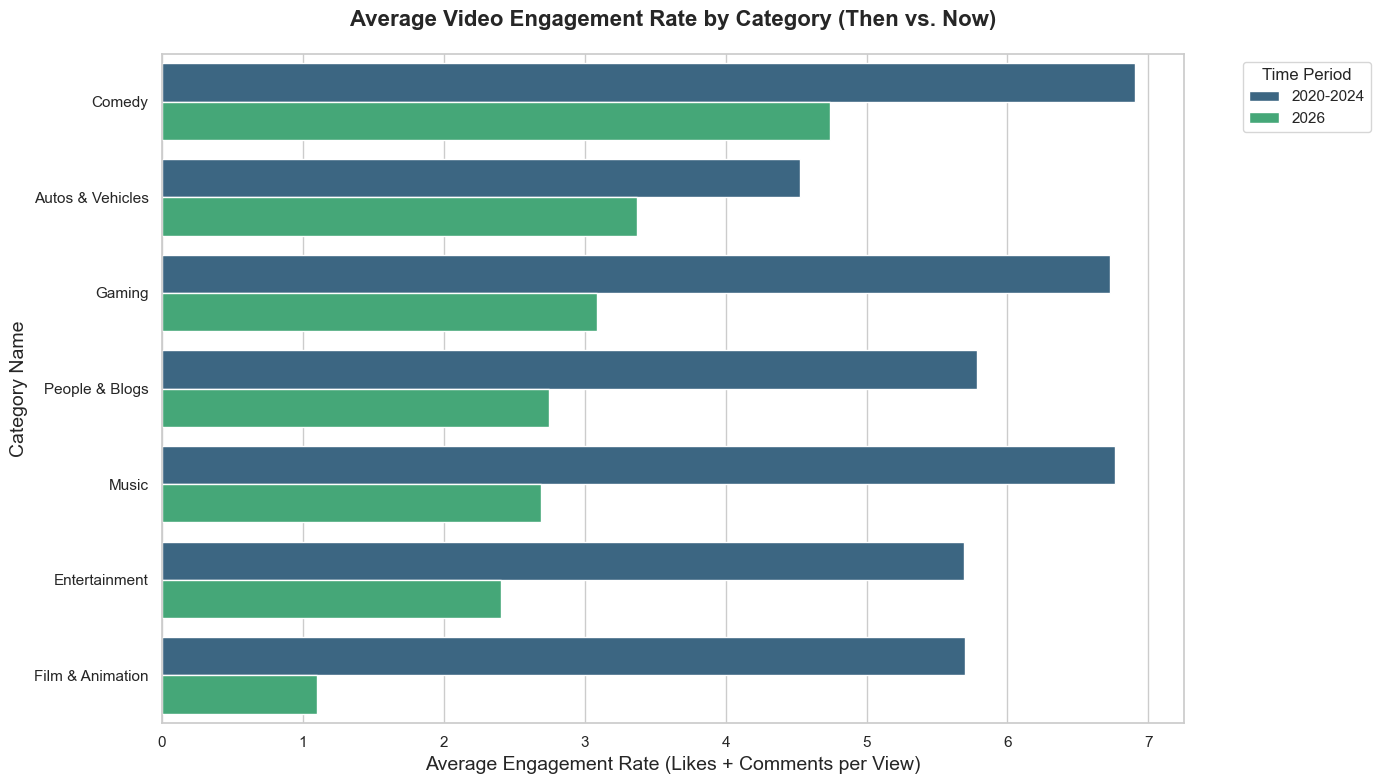

,Category Name,Time Period,Engagement Rate (%)
0,Comedy,2026,4.74%
1,Autos & Vehicles,2026,3.37%
2,Gaming,2026,3.09%
3,People & Blogs,2026,2.75%
4,Music,2026,2.69%
5,Entertainment,2026,2.41%
6,Film & Animation,2026,1.10%
7,Comedy,2020-2024,6.91%
8,Music,2020-2024,6.76%
9,Gaming,2020-2024,6.73%


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure a clean plotting style
sns.set_theme(style="whitegrid")

# 1. Calculate overall engagement metric (Combined Like and Comment Rates)
# You can also analyze 'like_rate' or 'comment_rate' individually if preferred
df["total_engagement_rate"] = df["like_rate"].fillna(0) + df[
    "comment_rate"
].fillna(0)

# 2. Aggregate the data by Category and Period
# We calculate the mean engagement rate for each group
engagement_data = (
    df.groupby(["category_name", "period"])["total_engagement_rate"]
    .mean()
    .reset_index()
)

# Sort categories by highest engagement in the most recent period for better readability
recent_period = "2026"
category_order = (
    engagement_data[engagement_data["period"] == recent_period]
    .sort_values(by="total_engagement_rate", ascending=False)["category_name"]
    .tolist()
)

# 3. Create the Visualization (Grouped Bar Chart)
plt.figure(figsize=(14, 8))

sns.barplot(
    data=engagement_data,
    x="total_engagement_rate",
    y="category_name",
    hue="period",
    order=category_order,
    palette="viridis",
)

# Customizing the chart details
plt.title(
    "Average Video Engagement Rate by Category (Then vs. Now)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Average Engagement Rate (Likes + Comments per View)", fontsize=14)
plt.ylabel("Category Name", fontsize=14)
plt.legend(title="Time Period", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# Display the plot
plt.show()

# 4. Print the exact numbers for your report


# 1. Sort the engagement data by period and highest engagement rate
engagement_df = engagement_data.sort_values(
    by=["period", "total_engagement_rate"], ascending=[False, False]
).reset_index(drop=True)

# 2. Make a copy to format numbers neatly without losing the original raw numbers
formatted_engagement_df = engagement_df.copy()

# 3. Rates are already in % -> only round (e.g., 6.9069 -> 6.91%)
formatted_engagement_df["total_engagement_rate"] = formatted_engagement_df[
    "total_engagement_rate"
].apply(lambda x: f"{x:.2f}%")

# 4. Rename columns for a more professional presentation look
formatted_engagement_df.columns = [
    "Category Name",
    "Time Period",
    "Engagement Rate (%)",
]

# Display the final polished DataFrame
formatted_engagement_df



### 4.1 Views per category

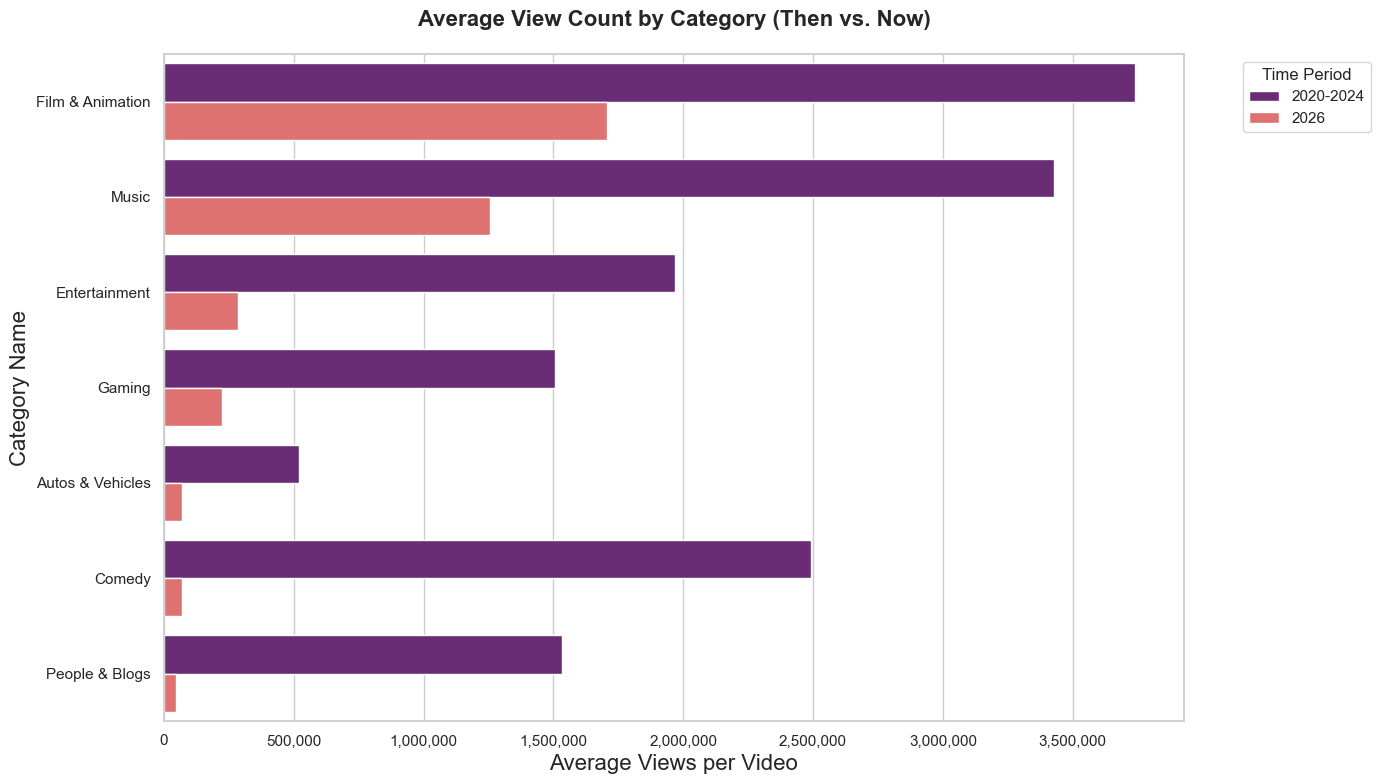

,category_name,period,avg_views,median_views,total_views,video_count
0,Film & Animation,2020-2024,"3,741,267","1,146,692","3,438,224,407",919
1,Music,2020-2024,"3,429,629","706,792","29,186,149,182","8,510"
2,Comedy,2020-2024,"2,491,504","554,293","3,931,593,895","1,578"
3,Entertainment,2020-2024,"1,968,311","315,835","27,959,862,500","14,205"
4,Science & Technology,2020-2024,"1,841,311","419,539","3,802,308,554","2,065"
5,People & Blogs,2020-2024,"1,533,550","252,230","8,687,563,522","5,665"
6,Gaming,2020-2024,"1,507,207","439,364","9,768,212,727","6,481"
7,Education,2020-2024,"1,447,234","489,764","2,234,529,583","1,544"
8,Sports,2020-2024,"1,181,422","412,335","9,035,518,231","7,648"
9,Travel & Events,2020-2024,"1,073,562","225,861","426,204,149",397


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure clean plotting style
sns.set_theme(style="whitegrid")

# 1. Aggregate the data by Category and Period
# We calculate both mean and median views (median is safer against extreme viral outliers)
views_data = (
    df.groupby(["category_name", "period"])["views"]
    .agg(["mean", "median"])
    .reset_index()
)

# Sort categories by highest mean views in the most recent period for a clean layout
recent_period = "2026"
category_order = (
    views_data[views_data["period"] == recent_period]
    .sort_values(by="mean", ascending=False)["category_name"]
    .tolist()
)

# 2. Create the Visualization (Grouped Bar Chart for Mean Views)
plt.figure(figsize=(14, 8))

sns.barplot(
    data=views_data,
    x="mean",
    y="category_name",
    hue="period",
    order=category_order,
    palette="magma",
)

# Customizing chart details
plt.title(
    "Average View Count by Category (Then vs. Now)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)
plt.xlabel("Average Views per Video", fontsize=16)
plt.ylabel("Category Name", fontsize=16)

# Format x-axis with commas for readability (e.g., 1,000,000)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ",")))

plt.legend(title="Time Period", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

# Display the plot
plt.show()

# 3. Print the data table for your analysis


# 1. Aggregate and calculate view statistics by Category and Period
# We include mean, median, and total views to give you a complete summary
views_df = (
    df.groupby(["category_name", "period"])["views"]
    .agg(
        avg_views="mean",
        median_views="median",
        total_views="sum",
        video_count="count",
    )
    .reset_index()
)

# 2. Sort the DataFrame chronologically by period, and descending by average views
views_df = views_df.sort_values(
    by=["period", "avg_views"], ascending=[True, False]
).reset_index(drop=True)

# 3. Format the numbers for clean, human-readable display in your notebook
formatted_df = views_df.copy()
for col in ["avg_views", "median_views", "total_views"]:
    formatted_df[col] = formatted_df[col].apply(lambda x: f"{int(x):,}")
formatted_df["video_count"] = formatted_df["video_count"].apply(
    lambda x: f"{x:,}"
)

# Display the formatted DataFrame (run this in a Jupyter Notebook cell)
formatted_df



**Category Performance (Then vs. Now)**

 Views ≠ Engagement: Mainstream categories (like Music and Film & Animation) dominate raw view counts, but Comedy has the highest engagement rate in 2020–2024. Music and Gaming are very close to each other (6.76% vs 6.73%), and in 2026 Gaming leads.

 Evolution of Trends: Comparing periods reveals a shift in the trending algorithm, showing which categories grew in volume (video_count) and viewer attention over time.

**Result (with numbers):**

**2020–2024 (Kaggle, ≈55k videos):**
- Highest engagement: **Comedy (6.91%)**, **Music (6.76%)**, **Gaming (6.73%)** — very close to each other
- Lowest engagement: **Sports (2.71%)** and **News & Politics (2.17%)**
- Highest views: **Film & Animation** and **Music** (median ≈1.15M and ≈707k views)

**2026 (API, 200 videos):**
- **Gaming dominates the trending list: 153 of 200 videos (≈77%)**, compared to only ≈12% of trending videos in 2020–2024
- Among categories with enough videos: **Gaming (3.09%)**, **Music (2.69%)**, **Entertainment (2.41%)**
- ⚠️ Comedy (2 videos), Autos & Vehicles (1) and People & Blogs (4) are too small to be reliable

**Insights:**
- **Views ≠ engagement:** Music and Film & Animation get the most views, but **Comedy** gets the highest engagement.
- The trending mix has changed a lot: today's German trending list is mostly **Gaming**. This also explains why **20–60 min videos** dominate (Question 2): gaming videos and streams are long.
- Engagement is generally **lower in 2026** than in 2020–2024 (≈2–3% vs. ≈5–7%). A possible reason: the API videos were collected only 1–2 days after publishing, while the Kaggle videos were measured on their last trending day.

→ **Hypothesis 3 ("Music has the highest engagement") is not supported** ❌ — Music is among the top 3, but Comedy is slightly higher (and Gaming leads in 2026).

---
## 5. Question 3: Does publish time matter? (Kaggle data)

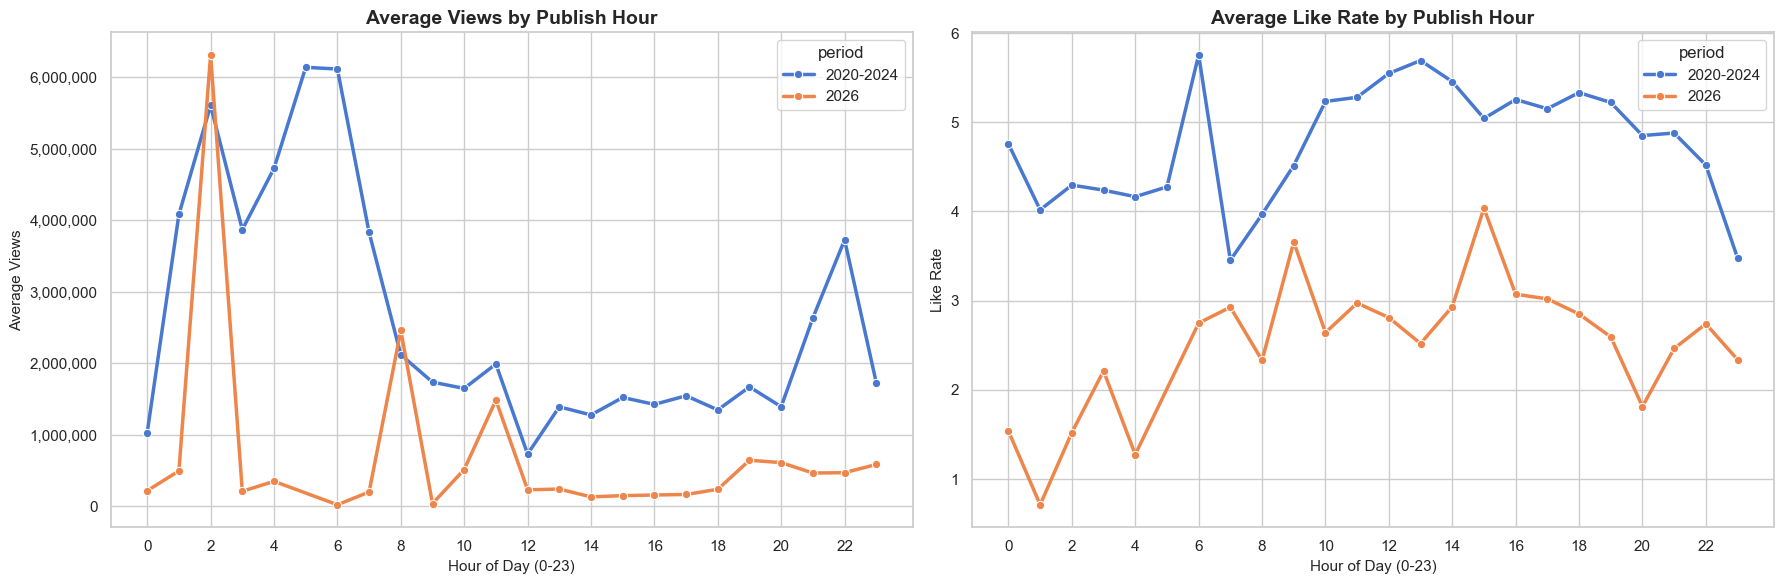

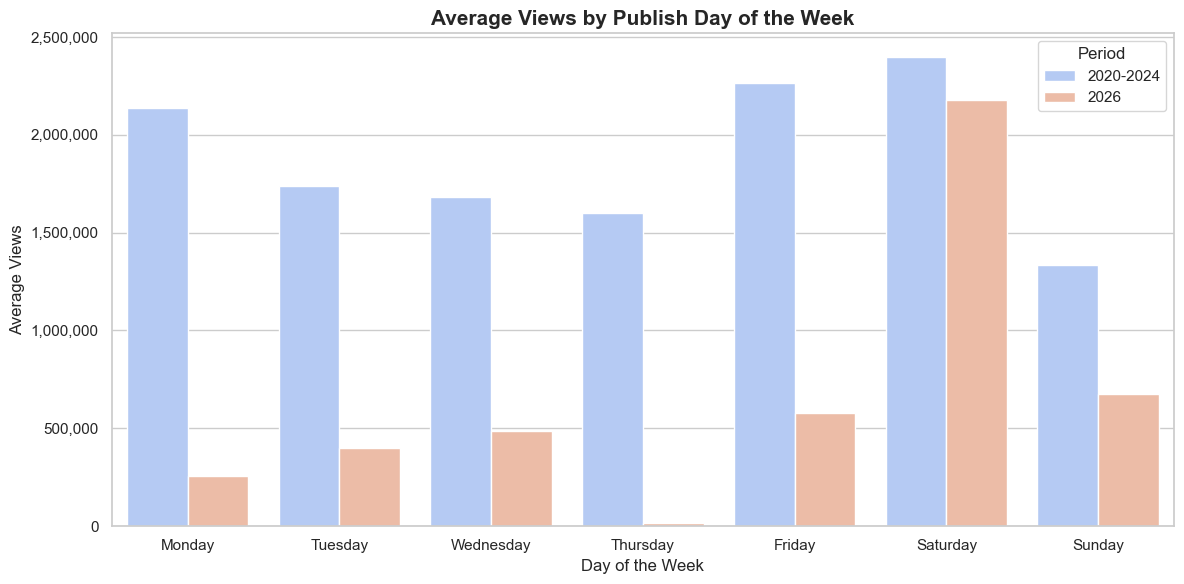

--- Best Upload Times & Days by Category (Sorted by Maximum / Most Views) ---


,period,category_name,publish_weekday,publish_time,most_viewed,avg_views,video_count
0,2020-2024,Entertainment,Monday,19:00,"1,407,643,634","7,451,517",212
1,2020-2024,Music,Friday,05:00,"219,110,491","22,215,195",91
2,2020-2024,Music,Friday,06:00,"206,344,829","9,290,048",562
3,2020-2024,Entertainment,Sunday,21:00,"176,598,344","7,722,444",56
4,2020-2024,Sports,Wednesday,22:00,"171,221,005","5,256,674",55
5,2020-2024,Entertainment,Thursday,01:00,"150,744,261","18,522,397",20
6,2020-2024,Education,Tuesday,04:00,"149,615,603","75,585,464",2
7,2020-2024,Gaming,Tuesday,00:00,"145,135,679","26,086,262",6
8,2020-2024,Entertainment,Wednesday,22:00,"130,743,617","6,340,986",38
9,2020-2024,Entertainment,Tuesday,02:00,"119,521,689","15,357,374",9


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure clean plotting style
sns.set_theme(style="whitegrid")

# ==============================================================================
# 1. ANALYSIS BY HOUROFDAY (publish_hour)
# ==============================================================================
# Aggregate views and engagement by hour and period
hourly_data = (
    df.groupby(["publish_hour", "period"])[["views", "like_rate"]]
    .mean()
    .reset_index()
)

# Create a multi-plot layout to see Views vs Likes side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Line plot for Hourly Views
sns.lineplot(
    data=hourly_data,
    x="publish_hour",
    y="views",
    hue="period",
    marker="o",
    linewidth=2.5,
    ax=axes[0],
    palette="muted",
)
axes[0].set_title(
    "Average Views by Publish Hour", fontsize=14, fontweight="bold"
)
axes[0].set_xlabel("Hour of Day (0-23)", fontsize=11)
axes[0].set_ylabel("Average Views", fontsize=11)
axes[0].set_xticks(range(0, 24, 2))
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ","))
)

# Line plot for Hourly Like Rate
sns.lineplot(
    data=hourly_data,
    x="publish_hour",
    y="like_rate",
    hue="period",
    marker="o",
    linewidth=2.5,
    ax=axes[1],
    palette="muted",
)
axes[1].set_title(
    "Average Like Rate by Publish Hour", fontsize=14, fontweight="bold"
)
axes[1].set_xlabel("Hour of Day (0-23)", fontsize=11)
axes[1].set_ylabel("Like Rate", fontsize=11)
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. ANALYSIS BY DAY OF WEEK (publish_weekday)
# ==============================================================================
# Aggregate views by day of the week and period
weekday_data = (
    df.groupby(["publish_weekday", "period"])["views"].mean().reset_index()
)

# Order the days correctly
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

plt.figure(figsize=(12, 6))
sns.barplot(
    data=weekday_data,
    x="publish_weekday",
    y="views",
    hue="period",
    order=day_order,
    palette="coolwarm",
)

plt.title(
    "Average Views by Publish Day of the Week", fontsize=15, fontweight="bold"
)
plt.xlabel("Day of the Week", fontsize=12)
plt.ylabel("Average Views", fontsize=12)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ","))
)
plt.legend(title="Period")
plt.tight_layout()
plt.show()

############################################


# 1. Aggregate data by Period, Category, Weekday, and Publish Hour
category_datetime_df = (
    df.groupby(["period", "category_name", "publish_weekday", "publish_hour"])[
        "views"
    ]
    .agg(
        most_viewed="max",
        avg_views="mean",
        video_count="count",
    )
    .reset_index()
)

# 2. Sort by Period, and then DESCENDING by the 'most_viewed' viral hit count
category_datetime_df = category_datetime_df.sort_values(
    by=["period", "most_viewed"], ascending=[True, False]
).reset_index(drop=True)

# 3. Format the integer hour into HH:MM string format
category_datetime_df["publish_time"] = category_datetime_df[
    "publish_hour"
].apply(lambda x: f"{int(x):02d}:00")

# Rearrange columns to put Category, Weekday, and Formatted Time upfront
columns_order = [
    "period",
    "category_name",
    "publish_weekday",
    "publish_time",
    "most_viewed",
    "avg_views",
    "video_count",
]
formatted_df = category_datetime_df[columns_order].copy()

# 4. Format numbers with commas for clean display
for col in ["most_viewed", "avg_views", "video_count"]:
    formatted_df[col] = formatted_df[col].apply(lambda x: f"{int(x):,}")

# Display the top rows of the highly granular breakdown
print(
    "--- Best Upload Times & Days by Category (Sorted by Maximum / Most Views) ---"
)
formatted_df.head(20)




**Result (Kaggle data, 2020–2024):**

We only use the **2020–2024** results here: the 2026 data is biased (80% of the API videos were published on Monday).

**Weekday (average views):**
- Highest: **Saturday (≈2.40M)**, **Friday (≈2.26M)**, **Monday (≈2.14M)**
- Lowest: **Sunday (≈1.33M)**
- Weekend vs. weekdays: weekend videos have **slightly fewer** views on average (≈1.77M vs. ≈1.89M)

**Hour (German time):**
- Most trending videos are published in the **afternoon/evening (16:00–19:00)**, with a peak at **18:00**
- Videos published **early in the morning (01:00–06:00)** have the **highest average views**, but there are only few of them. Many are international releases (e.g. K-pop music videos like BTS and BLACKPINK were published around 04:00 German time)

→ **Hypothesis 4 ("weekend videos get more views") is not supported** ❌ — Saturday is strong, but Sunday is the weakest day, so the weekend as a whole is not better.

⚠️ These are **averages**, which are pulled up by a few viral videos (see the "most viewed" table: many top rows are single videos). The medians show much smaller differences between days (≈330k–390k views).

## 6. Question 4: Do clickbait-style titles get more views? (Kaggle data)

**Hypothesis:** Titles with `!`, `?` or a word in CAPITAL LETTERS get more views.

We use only the **Kaggle data**: the API videos were measured only 1–2 days after publishing, so their views are not comparable.

In [23]:
# Kaggle rows only
kaggle_df = df[df["period"] == "2020-2024"].copy()
kaggle_df = kaggle_df.dropna(subset=["title"])

# True/False columns for each clickbait sign
kaggle_df["has_exclamation"] = kaggle_df["title"].str.contains("!", regex=False)
kaggle_df["has_question"] = kaggle_df["title"].str.contains("?", regex=False)

`regex=False` is needed because `?` has a special meaning in regex patterns. With `regex=False`, pandas searches for the normal character.

In [24]:
# A word counts as CAPS if it is all upper case and has at least 4 letters (e.g. "SHOCKING")
def has_caps_word(title):
    for word in title.split():
        if word.isupper() and len(word) >= 4:
            return True
    return False

kaggle_df["has_caps_word"] = kaggle_df["title"].apply(has_caps_word)

# Clickbait = at least one of the three signs
kaggle_df["clickbait"] = kaggle_df["has_exclamation"] | kaggle_df["has_question"] | kaggle_df["has_caps_word"]

kaggle_df[["has_exclamation", "has_question", "has_caps_word", "clickbait"]].sum()

has_exclamation    11800
has_question        5474
has_caps_word      23752
clickbait          31353
dtype: int64

In [25]:
# Median views, like-rate and comment-rate: clickbait vs. normal titles
kaggle_df.groupby("clickbait")[["views", "like_rate", "comment_rate"]].median()

,views,like_rate,comment_rate
clickbait,,,
False,520881.5,4.144832,0.234054
True,293753.0,4.692126,0.248908


In [26]:
# Median views with and without each sign
results = []

for col in ["has_exclamation", "has_question", "has_caps_word", "clickbait"]:
    medians = kaggle_df.groupby(col)["views"].median()
    results.append({"sign": col, "with": medians[True], "without": medians[False]})

results_df = pd.DataFrame(results)
results_df

,sign,with,without
0,has_exclamation,254496.5,416997.0
1,has_question,237099.5,392769.0
2,has_caps_word,305083.0,425706.0
3,clickbait,293753.0,520881.5


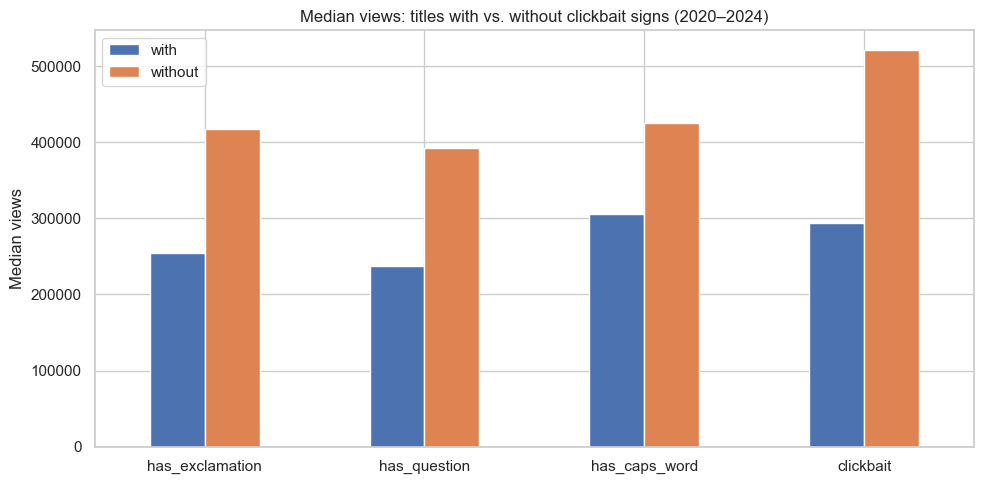

In [27]:
results_df.plot(x="sign", y=["with", "without"], kind="bar", figsize=(10, 5))
plt.title("Median views: titles with vs. without clickbait signs (2020–2024)")
plt.ylabel("Median views")
plt.xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Result (Kaggle data, 2020–2024):**

| Sign | Median views with | Median views without | Difference |
|---|---|---|---|
| `!` | 254,497 | 416,997 | −39% |
| `?` | 237,100 | 392,769 | **−40%** (biggest gap) |
| CAPS word | 305,083 | 425,706 | −28% |
| **Clickbait (any sign)** | **293,753** | **520,882** | **−44%** |

**Insights:**
- For **every** sign, titles **without** it have more views. Clickbait titles get about **44% fewer** median views.
- Question marks and exclamation marks show the biggest gap; CAPS words the smallest.
- A possible reason (not tested): big channels like music labels and film studios use plain titles, while smaller creators use clickbait to get attention.

→ **Hypothesis 4 ("clickbait titles get more views") is not supported** ❌ — the opposite is true.

⚠️ Limitation: short brand names in capitals (e.g. "FIFA", "BTS") are also counted as CAPS words.

---
## 7. Conclusion

| # | Hypothesis | Result | Key number |
|---|---|---|---|
| 1 | Shorter videos (incl. Shorts) get more engagement | ❌ not supported | Shorts 1.74% vs. long 2.68% · 20–60 min highest (2.79%) |
| 2 | Music has the highest engagement | ❌ not supported | Comedy 6.91% > Music 6.76% (2020–2024) |
| 3 | Weekend videos get more views | ❌ not supported | Saturday highest, Sunday lowest |
| 4 | Clickbait titles get more views | ❌ not supported (opposite) | median views 293,753 (clickbait) vs. 520,882 (normal), −44% |

**Main takeaways:**
- **Longer videos** (20–60 min) engage viewers more than short ones.
- **Views ≠ engagement:** the categories with the most views are not the ones with the highest like/comment rates.
- German trending has shifted strongly towards **Gaming** (≈77% of trending videos today vs. ≈12% in 2020–2024).
- Publish **time** matters less than expected; averages are driven by a few viral videos.
- **Clickbait titles** (`!`, `?`, CAPS) get fewer views, not more.

### Limitations
- Trending = only the **most successful** videos, not all of YouTube
- API = **one day** (200 videos), Kaggle = **3.5 years** (≈55k videos) → we compare medians/averages and percentages, not counts
- Kaggle has **no duration** → Question 1 uses only 200 videos; some groups are very small
- "Short" is defined by length (≤ 3 min), not by YouTube's own label

### Next steps
- Collect API data over **several days/weeks** for a fairer comparison
- Look into **why Gaming** dominates trending today
- Use `video_id` to fetch **duration for Kaggle videos** via the API